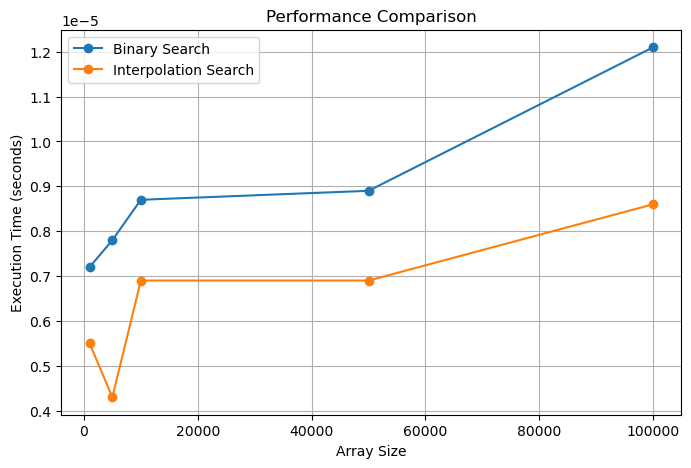

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt


# Binary Search
def binary_search(arr, key):
    low = 0
    high = len(arr)-1
    comparisons = 0

    while low <= high:
        mid = (low + high) // 2
        comparisons += 1

        if arr[mid] == key:
            return mid, comparisons

        elif arr[mid] < key:
            low = mid + 1

        else:
            high = mid - 1

    return -1, comparisons



# Interpolation Search
def interpolation_search(arr, key):

    low = 0
    high = len(arr)-1
    comparisons = 0

    while low <= high and arr[low] <= key <= arr[high]:

        # avoid division by zero
        if arr[high] == arr[low]:
            break

        pos = low + ((key - arr[low]) * (high - low)) // (arr[high] - arr[low])

        comparisons += 1

        if arr[pos] == key:
            return pos, comparisons

        elif arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    return -1, comparisons



# Array sizes
sizes = [1000, 5000, 10000, 50000, 100000]

results = []


# Testing
for size in sizes:

    arr = sorted(random.sample(range(1,1000000), size))

    key = arr[size//2]


    # Binary Search
    start = time.perf_counter()

    index1, comp1 = binary_search(arr,key)

    end = time.perf_counter()

    binary_time = end - start



    # Interpolation Search
    start = time.perf_counter()

    index2, comp2 = interpolation_search(arr,key)

    end = time.perf_counter()

    interpolation_time = end - start



    results.append([
        size,
        binary_time,
        interpolation_time,
        comp1,
        comp2
    ])



# Create Table
df = pd.DataFrame(
    results,
    columns=[
        "Array Size",
        "Binary Search Time",
        "Interpolation Search Time",
        "Binary Comparisons",
        "Interpolation Comparisons"
    ]
)


# Display table

plt.figure(figsize=(8,5))

plt.plot(
    df["Array Size"],
    df["Binary Search Time"],
    marker="o",
    label="Binary Search"
)

plt.plot(
    df["Array Size"],
    df["Interpolation Search Time"],
    marker="o",
    label="Interpolation Search"
)


plt.xlabel("Array Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Comparison")

plt.legend()
plt.grid()

plt.show()